# 15. The `Pole` lineshape

**Objectives:** evaluate a standalone fixed-width `Pole` amplitude, trace its Argand
diagram, embed it in a one-resonance `DecayModel`, and recover its pole mass from a
toy fit.

Run cells top to bottom in a fresh kernel. Masses are in GeV, invariants in GeV²,
daughter indices start at zero. `Pole` is Laura++ Eq. 37: a simple fixed-width pole
`1 / (m - m0 - i*Gamma0/2)`, with no barrier factor or energy-dependent width of its
own.

In [1]:
from dalitzplotfitter import enable_x64
enable_x64()

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from dalitzplotfitter import (
    DecayChannel, DecayModel, NonResonant, Parameter, Pole, RealImag,
    Resonance, ResonanceContext, FitSession, generate_toy,
)

## 1. Standalone amplitude and Argand diagram

`Pole` reads `pole_mass`/`pole_width` from a `ResonanceContext`; everything else in
the context is irrelevant to it. As `m` sweeps across the pole, the amplitude traces
a circle in the complex plane and its phase advances continuously through the pole
mass -- the textbook fixed-width Breit-Wigner behaviour.

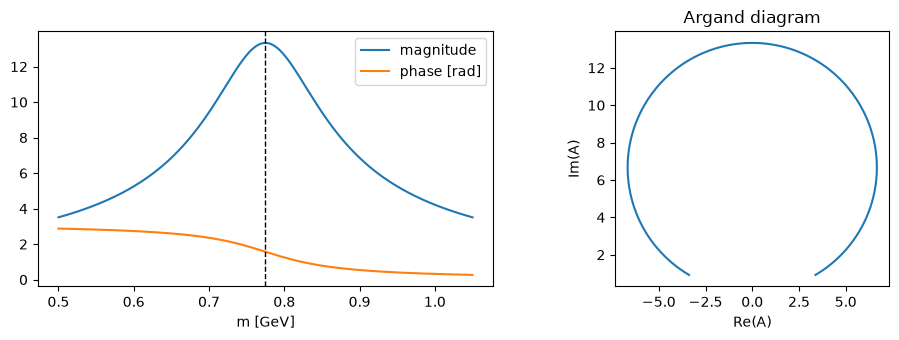

In [2]:
context = ResonanceContext(
    parent_mass=1.869, daughter_masses=(0.13957, 0.13957),
    bachelor_mass=0.13957, spin=0, pole_mass=0.775, pole_width=0.150,
)
mass_scan = jnp.linspace(0.5, 1.05, 400)
amplitude = Pole()(mass_scan, context)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(mass_scan, jnp.abs(amplitude), label="magnitude")
axes[0].plot(mass_scan, jnp.angle(amplitude), label="phase [rad]")
axes[0].axvline(0.775, color="black", linestyle="--", linewidth=1)
axes[0].set(xlabel="m [GeV]")
axes[0].legend()
axes[1].plot(np.asarray(amplitude).real, np.asarray(amplitude).imag)
axes[1].set(xlabel="Re(A)", ylabel="Im(A)", title="Argand diagram", aspect="equal")
fig.tight_layout()
plt.show()

## 2. A one-resonance Dalitz model

`Pole` plugs into `Resonance` like any other `lineshape`. Here it describes the
`(0, 1)` pair (`pi- pi+`) of a `D+ -> pi- pi+ pi+` toy channel, spin 0.

In [3]:
channel = DecayChannel("D+", ("pi-", "pi+", "pi+"))
mass = Parameter.dynamics("S.mass", 0.775, owner="S", bounds=(0.70, 0.85), step=0.001)
model = DecayModel(
    channel,
    components=[
        Resonance("S", (0, 1), RealImag(1.0, 0.0), lineshape=Pole(),
                  mass=mass, width=0.150, spin=0),
        NonResonant(RealImag(0.30, -0.15), name="NR"),
    ],
    normalization_method="square-dalitz", normalization_pair=(0, 1),
    normalization_resolution=60,
)
truth = {"S.mass": 0.775}
print("Parameters:", [p.name for p in model.parameters])

Parameters: ['S.mass']


## 3. Generate a toy and fit the pole mass

The toy is generated at the truth mass; the fit starts elsewhere and must recover it.

In [4]:
data = generate_toy(
    model, 1500, parameters=truth, seed=15,
    method="inverse-transform", inverse_resolution=256, include_momenta=False,
)
print(f"Generated {data.size} events")

session = FitSession(model, data)
result = session.fit({"S.mass": 0.79}, simplex=True, ncall=5000)
session.report(result)
assert result.valid, "Inspect the fit diagnostics before trusting this result."


Generated 1500 events


valid=True  NLL=1706.926649
parameter                           value            error
S.mass                           0.773652       0.00266609


Fit fractions (physical)
component                    fraction [%]
S                                  91.416
NR                                 10.284
sum                               101.700


## 4. Sanity check

The fitted pole mass must land close to the generation truth, within a few times its
Minuit error.

In [5]:
fitted_mass = float(result.values["S.mass"])
error = float(result.errors["S.mass"])
print(f"truth={truth['S.mass']:.4f}, fit={fitted_mass:.4f}, error={error:.4f}")
np.testing.assert_allclose(fitted_mass, truth["S.mass"], atol=8 * error)
print("Pole mass recovered within 8 sigma of its Minuit error.")

truth=0.7750, fit=0.7737, error=0.0027
Pole mass recovered within 8 sigma of its Minuit error.


## Continue learning

Contrast this fixed-width pole with the [`SigmaPole` convention](tutorial_16_sigma_pole.ipynb),
which places the width inside the pole location itself rather than adding an `i*Gamma/2`
term. See [lineshapes](../../docs/lineshapes.md).

Return to [the course guide](TUTORIALS.md).